</table><table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Aplicación de algoritmos de clasificación para la detección temprana de abandono laboral
        </td>
    </tr>
    <tr>
 

</table>

## Descripción del Problema

El conjunto de datos de predicción de rotación de empleados contiene información de **10,000 empleados**, diseñado para el modelado predictivo y el análisis de la rotación laboral. Incluye una variedad de métricas demográficas, laborales y de desempeño que ayudan a comprender los factores que contribuyen a la salida o abandono de los empleados en una organización.

**Variable objetivo:** `Attrition` — Indica si el empleado dejó la empresa: `Yes` o `No`.

Se aplicarán los siguientes algoritmos de clasificación:
1. **Regresión Logística**
2. **Algoritmo KNN (K-Nearest Neighbors)**
3. **Árbol de Decisiones**

Para cada algoritmo se evaluarán **varios ejemplos** (variando hiperparámetros) a fin de definir la mejor respuesta predictiva.

In [378]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
#import dataframe_image as dfi

import warnings
warnings.filterwarnings('ignore')

## 1. Carga y Exploración del Conjunto de Datos

In [379]:
# Cargar el conjunto de datos
df = pd.read_csv('clasificacion.csv')
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [380]:
# Dimensiones del dataset
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 1000, Columnas: 26


In [381]:
# Información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    1000 non-null   int64
 1   Age                            1000 non-null   int64
 2   Gender                         1000 non-null   str  
 3   Marital_Status                 1000 non-null   str  
 4   Department                     1000 non-null   str  
 5   Job_Role                       1000 non-null   str  
 6   Job_Level                      1000 non-null   int64
 7   Monthly_Income                 1000 non-null   int64
 8   Hourly_Rate                    1000 non-null   int64
 9   Years_at_Company               1000 non-null   int64
 10  Years_in_Current_Role          1000 non-null   int64
 11  Years_Since_Last_Promotion     1000 non-null   int64
 12  Work_Life_Balance              1000 non-null   int64
 13  Job_Satisfaction              

In [382]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.991000,3.055000,11499.899000,57.837000,14.922000,7.539000,4.40800,2.495000,3.151000,2.52700,50.043000,4.877000,44.553000,9.524000,2.494000,2.519000,2.503000,24.507000,2.484000
std,288.819436,11.780055,1.399977,4920.529231,24.702037,8.350548,4.001061,2.99508,1.105077,1.426967,1.13073,28.204657,2.546833,8.704192,5.973534,1.110494,1.106736,1.099636,14.138099,1.111296
min,1.000000,20.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.00000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.750000,30.000000,2.000000,7395.750000,36.000000,8.000000,4.000000,2.00000,2.000000,2.000000,2.00000,26.000000,3.000000,37.000000,4.000000,2.000000,2.000000,2.000000,12.000000,1.000000
50%,500.500000,41.000000,3.000000,11256.000000,58.000000,15.000000,8.000000,4.00000,3.000000,3.000000,3.00000,50.000000,5.000000,45.000000,9.000000,2.000000,3.000000,3.000000,24.000000,2.000000
75%,750.250000,50.250000,4.000000,15855.000000,80.000000,22.000000,11.000000,7.00000,3.000000,4.000000,4.00000,75.250000,7.000000,52.000000,15.000000,4.000000,4.000000,3.000000,37.000000,3.000000
max,1000.000000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.00000,4.000000,5.000000,4.00000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


In [383]:
# Distribución de la variable objetivo Attrition
print(df['Attrition'].value_counts())
print()
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     811
Yes    189
Name: count, dtype: int64

Attrition
No     81.1
Yes    18.9
Name: proportion, dtype: float64


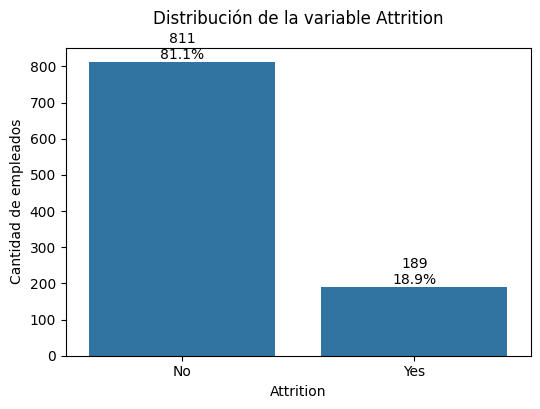

In [384]:
# Gráfico de distribución de la variable objetivo
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Attrition', data=df)
total = len(df)
for p in ax.patches:
    cantidad = int(p.get_height())
    porcentaje = cantidad / total * 100
    ax.annotate(f'{cantidad}\n{porcentaje:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.title('Distribución de la variable Attrition', y=1.05)
plt.xlabel('Attrition')
plt.ylabel('Cantidad de empleados')
plt.show()

## 2. Análisis Exploratorio de Datos (EDA)

<Figure size 640x480 with 0 Axes>

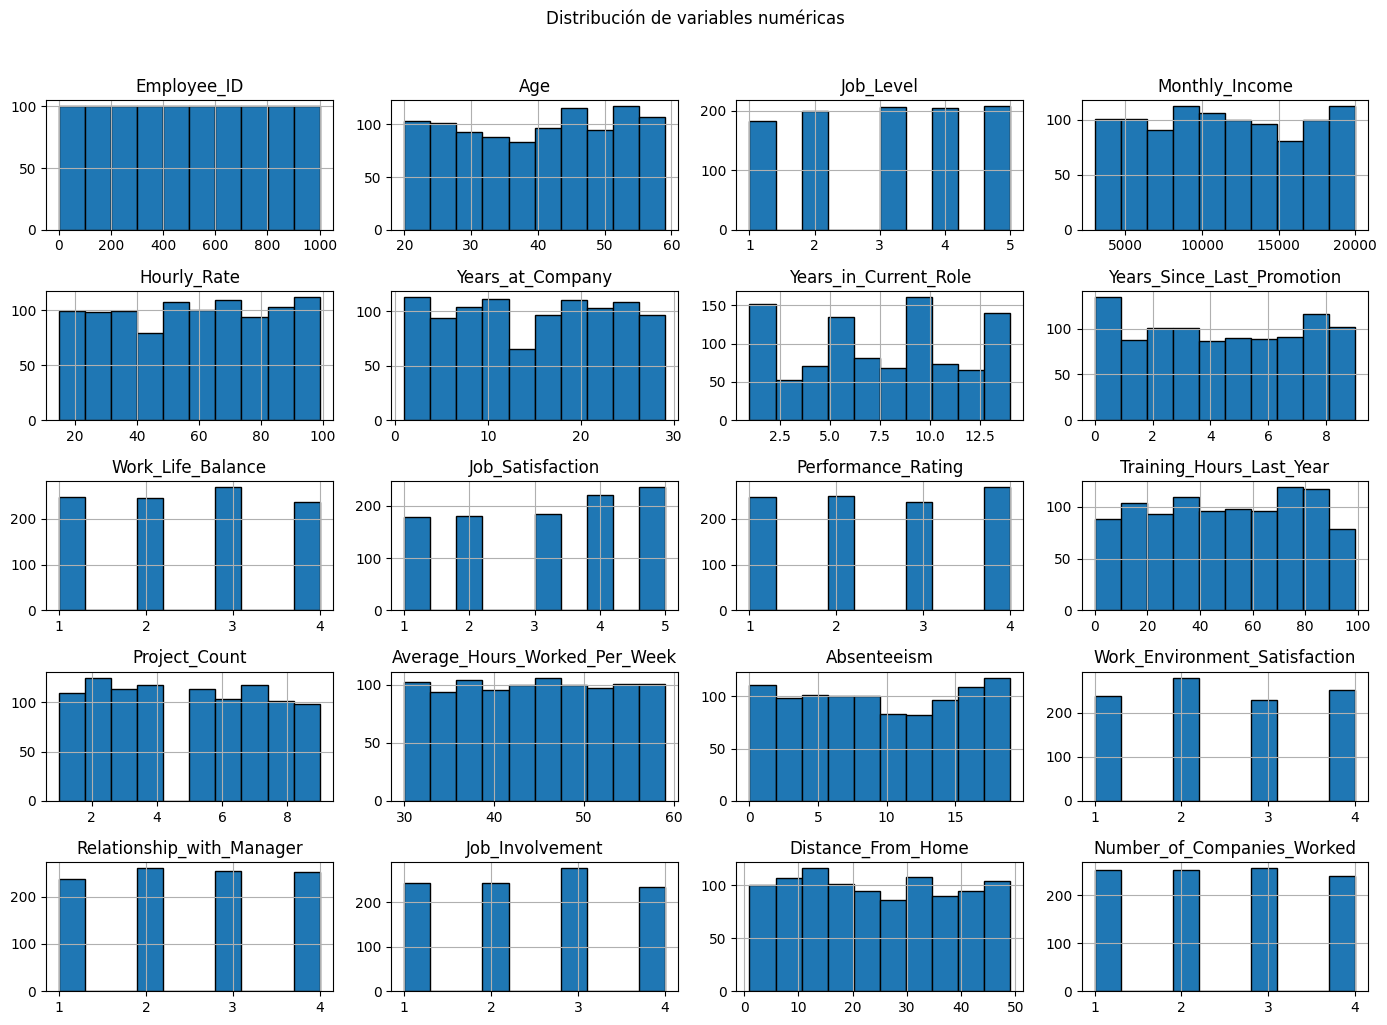

In [385]:
# Histogramas de las variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure()
df[numeric_cols].hist(figsize=(14, 10), edgecolor='black')
plt.suptitle('Distribución de variables numéricas', y=1.02)
plt.tight_layout()
plt.show()

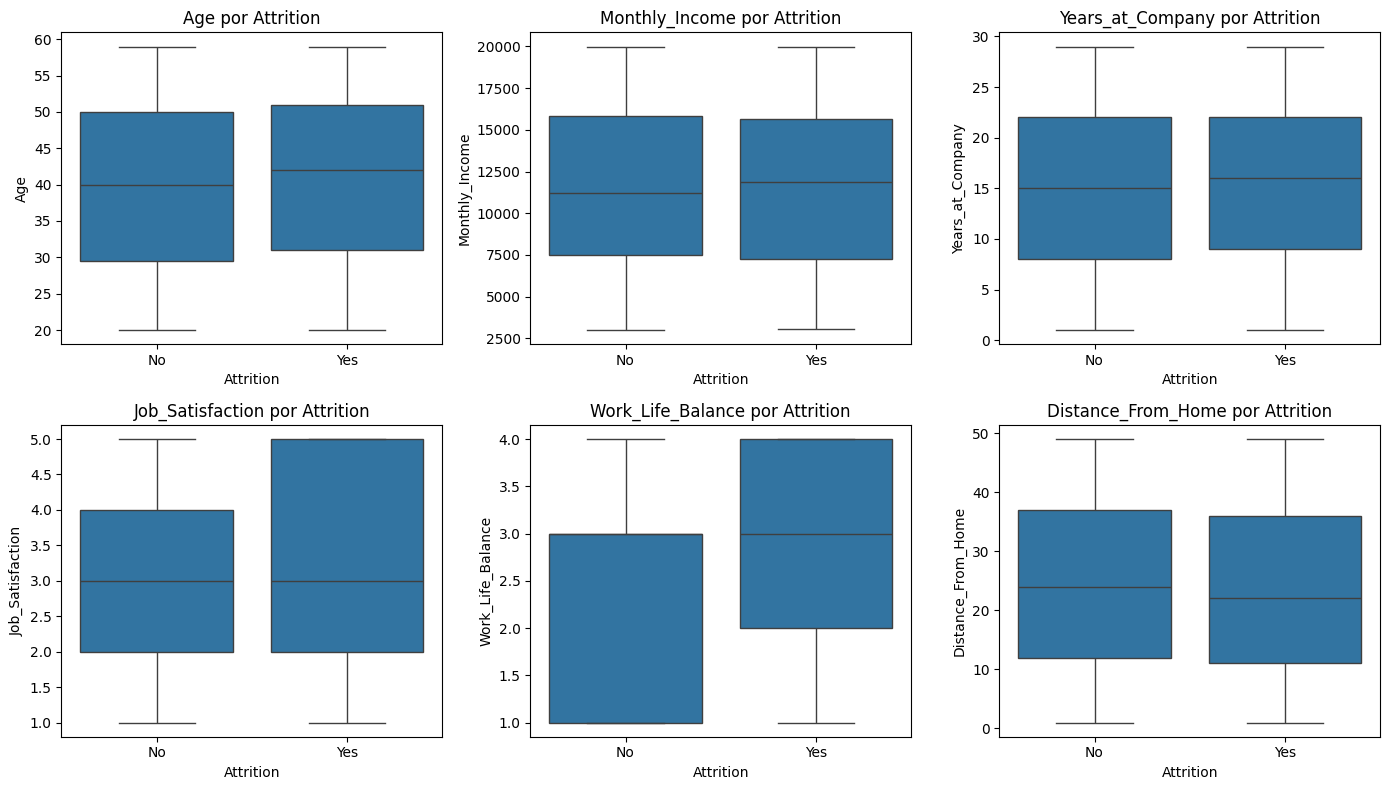

In [386]:
# Boxplots de variables clave según Attrition
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

vars_to_plot = ['Age', 'Monthly_Income', 'Years_at_Company',
                'Job_Satisfaction', 'Work_Life_Balance', 'Distance_From_Home']

for ax, var in zip(axes.flatten(), vars_to_plot):
    sns.boxplot(x='Attrition', y=var, data=df, ax=ax)
    ax.set_title(f'{var} por Attrition')

plt.tight_layout()
plt.show()

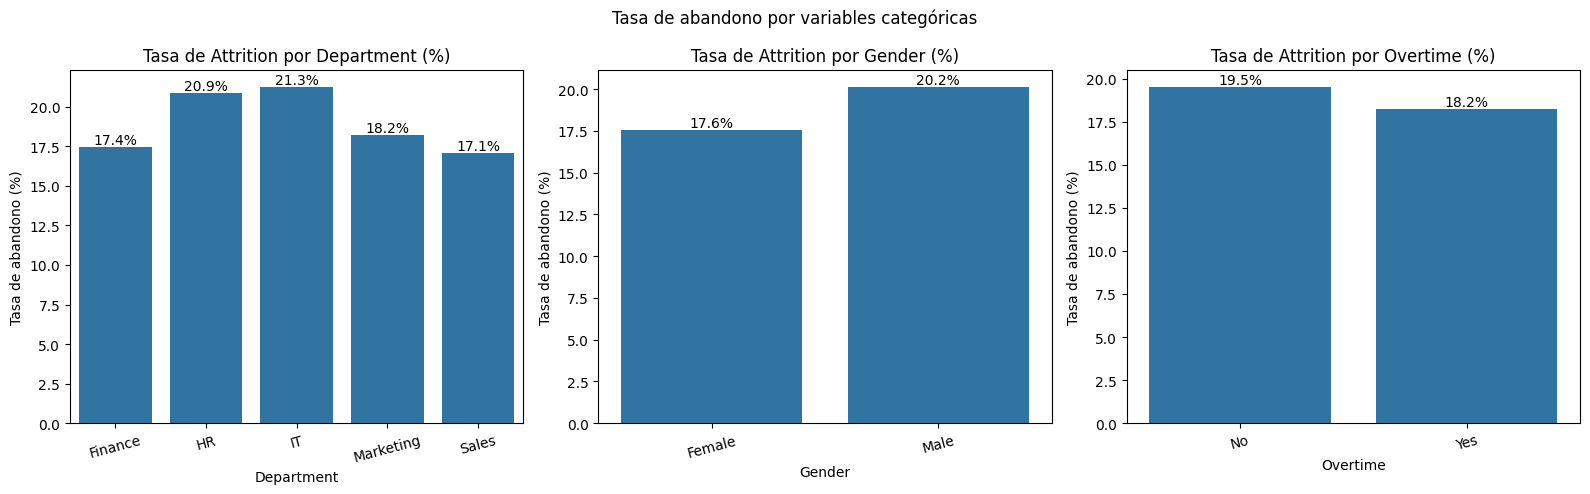

In [387]:
# Attrition por variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Department', 'Gender', 'Overtime']):
    attrition_rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    attrition_rate.columns = [col, 'Attrition_Rate']
    sns.barplot(x=col, y='Attrition_Rate', data=attrition_rate, ax=ax)
    for p in ax.patches:
        porcentaje = p.get_height()
        ax.annotate(f'{porcentaje:.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom')
    ax.set_title(f'Tasa de Attrition por {col} (%)')
    ax.set_ylabel('Tasa de abandono (%)')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Tasa de abandono por variables categóricas')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento de Datos

In [388]:
# Eliminar columna identificadora (no aporta información predictiva)
df_model = df.drop(columns=['Employee_ID'])

# Codificar variables categóricas con LabelEncoder
le = LabelEncoder()
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print("Variables categóricas a codificar:", categorical_cols)

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

Variables categóricas a codificar: ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime', 'Attrition']


,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,58,0,1,2,3,1,15488,28,15,4,...,0,6,54,17,4,4,4,20,3,0
1,48,0,1,4,1,5,13079,28,6,9,...,1,2,45,1,4,1,2,25,2,0
2,34,1,1,3,1,1,13744,24,24,14,...,1,6,34,2,3,4,4,45,3,0
3,27,0,0,3,3,1,6809,26,10,8,...,0,9,48,18,2,3,1,35,3,0
4,40,1,0,3,2,1,10206,52,29,10,...,0,3,33,0,4,1,3,44,3,0


In [389]:
# Separar variables predictoras (X) y variable objetivo (y)
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

# Dividir en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=2026
)

print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")

Tamaño entrenamiento: (800, 24)
Tamaño prueba: (200, 24)


In [390]:
# Escalar las variables (necesario para Regresión Logística y KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## 4. Regresión Logística

La **Regresión Logística** es un modelo de clasificación que estima la probabilidad de que una observación pertenezca a una clase determinada. Utiliza la función sigmoide para mapear valores reales al intervalo [0, 1].

Se evaluarán tres configuraciones distintas:
- **a)** Parámetros por defecto
- **b)** Regularización L1 (lasso)
- **c)** Mayor número de iteraciones con penalización L2

### a) Regresión Logística con parámetros por defecto

In [391]:
# Crear el objeto de clase Regresión Logística con parámetros por defecto
lr_a = LogisticRegression(random_state=2026)
# Ajustar el modelo
lr_a.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [392]:
# Obtener predicciones
y_pred_lr_a = lr_a.predict(X_test_scaled)

# Accuracy Score
accuracy_lr_a = accuracy_score(y_test, y_pred_lr_a)
print("El accuracy score que se tiene es %s" % accuracy_lr_a)

El accuracy score que se tiene es 0.785


Text(50.722222222222214, 0.5, 'Real')

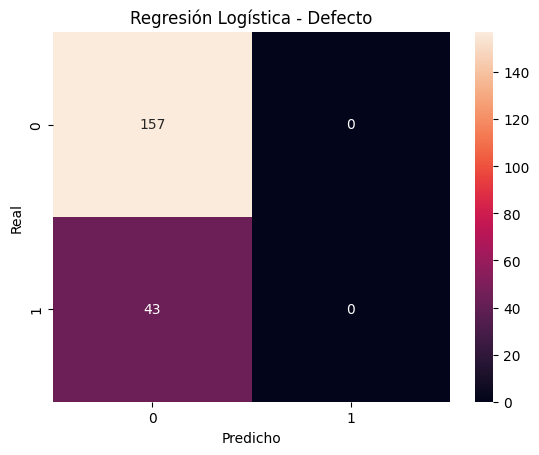

In [393]:
from sklearn.metrics import confusion_matrix

# Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr_a)
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Regresión Logística - Defecto")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [394]:
# Obtener la precisión, recall y f1
precision_lr_a = precision_score(y_test, y_pred_lr_a, average="macro")
recall_lr_a = recall_score(y_test, y_pred_lr_a, average="macro")
f1_lr_a = f1_score(y_test, y_pred_lr_a, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_lr_a, recall_lr_a, f1_lr_a]})
metricas

,Métricas,Valores
0,Precisión,0.392500
1,Recall,0.500000
2,F1,0.439776


### b) Regresión Logística con regularización L1 (Lasso)

La regularización L1 produce modelos más dispersos al forzar algunos coeficientes a cero, actuando como un selector automático de variables.

In [395]:
# Crear el objeto de clase Regresión Logística con regularización L1
lr_b = LogisticRegression(penalty='l1', solver='liblinear', random_state=2026)
# Ajustar el modelo
lr_b.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [396]:
# Obtener predicciones
y_pred_lr_b = lr_b.predict(X_test_scaled)

# Accuracy Score
accuracy_lr_b = accuracy_score(y_test, y_pred_lr_b)
print("El accuracy score que se tiene es %s" % accuracy_lr_b)

El accuracy score que se tiene es 0.785


Text(50.722222222222214, 0.5, 'Real')

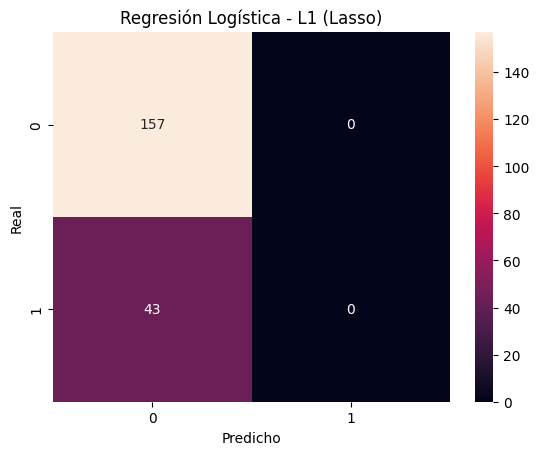

In [397]:
# Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Regresión Logística - L1 (Lasso)")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [398]:
# Obtener la precisión, recall y f1
precision_lr_b = precision_score(y_test, y_pred_lr_b, average="macro")
recall_lr_b = recall_score(y_test, y_pred_lr_b, average="macro")
f1_lr_b = f1_score(y_test, y_pred_lr_b, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_lr_b, recall_lr_b, f1_lr_b]})
metricas

#dfi.export(metricas, "metricas_arbol_max_depth_5.png")

,Métricas,Valores
0,Precisión,0.392500
1,Recall,0.500000
2,F1,0.439776


### c) Regresión Logística con mayor número de iteraciones y C=0.5

Reducir el valor de `C` aumenta la regularización, lo que puede mejorar la generalización del modelo.

In [399]:
# Crear el objeto de clase Regresión Logística con C=0.5 y max_iter=500
lr_c = LogisticRegression(C=0.5, max_iter=500, random_state=2026)
# Ajustar el modelo
lr_c.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [400]:
# Obtener predicciones
y_pred_lr_c = lr_c.predict(X_test_scaled)

# Accuracy Score
accuracy_lr_c = accuracy_score(y_test, y_pred_lr_c)
print("El accuracy score que se tiene es %s" % accuracy_lr_c)

El accuracy score que se tiene es 0.785


Text(50.722222222222214, 0.5, 'Real')

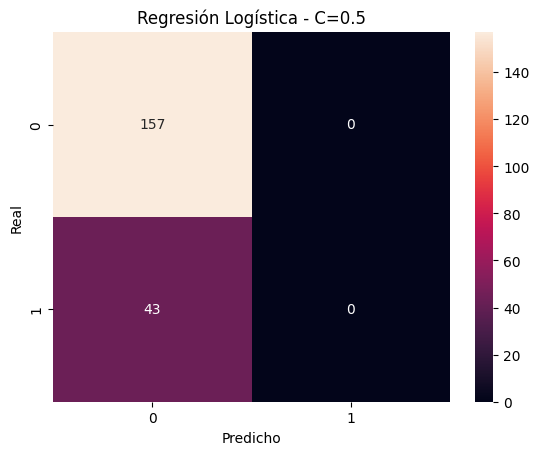

In [401]:
# Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr_c)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Regresión Logística - C=0.5")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [402]:
# Obtener la precisión, recall y f1
precision_lr_c = precision_score(y_test, y_pred_lr_c, average="macro")
recall_lr_c = recall_score(y_test, y_pred_lr_c, average="macro")
f1_lr_c = f1_score(y_test, y_pred_lr_c, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_lr_c, recall_lr_c, f1_lr_c]})
metricas

,Métricas,Valores
0,Precisión,0.392500
1,Recall,0.500000
2,F1,0.439776


### Comparación de los modelos de Regresión Logística

A continuación se resumen las métricas de los tres modelos de Regresión Logística evaluados:

In [403]:
comparacion_lr = pd.DataFrame({
    'Modelo': ['RL - Defecto', 'RL - L1 (Lasso)', 'RL - C=0.5, iter=500'],
    'Accuracy': [accuracy_lr_a, accuracy_lr_b, accuracy_lr_c],
    'Precisión': [precision_lr_a, precision_lr_b, precision_lr_c],
    'Recall': [recall_lr_a, recall_lr_b, recall_lr_c],
    'F1': [f1_lr_a, f1_lr_b, f1_lr_c]
})
comparacion_lr

,Modelo,Accuracy,Precisión,Recall,F1
0,RL - Defecto,0.785,0.3925,0.5,0.439776
1,RL - L1 (Lasso),0.785,0.3925,0.5,0.439776
2,"RL - C=0.5, iter=500",0.785,0.3925,0.5,0.439776


---
## 5. K-Nearest Neighbors (KNN)
El algoritmo **KNN** clasifica una observación en función de la clase mayoritaria entre sus `k` vecinos más cercanos en el espacio de características.

Se evaluarán tres configuraciones:
- **a)** k=5 (valor por defecto)
- **b)** k=3
- **c)** k=11

### a) KNN con k=5 (parámetros por defecto)

In [404]:
# Crear el objeto de clase KNN con parámetros por defecto (k=5)
knn_a = KNeighborsClassifier()
# Ajustar el modelo
knn_a.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [405]:
# Obtener el accuracy score
y_pred_knn_a = knn_a.predict(X_test_scaled)
accuracy_knn_a = accuracy_score(y_test, y_pred_knn_a)
print("El accuracy score que se tiene es %s" % accuracy_knn_a)

El accuracy score que se tiene es 0.77


Text(50.722222222222214, 0.5, 'Real')

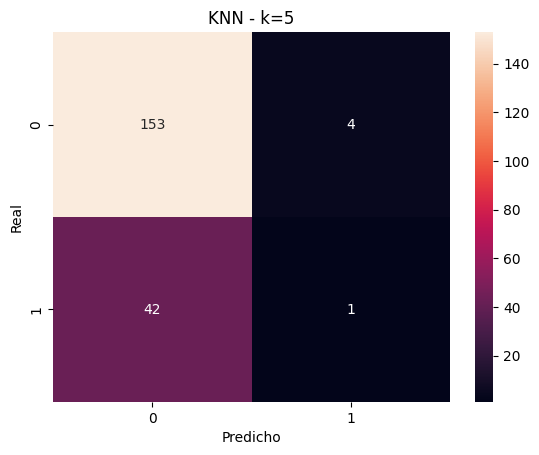

In [406]:
# Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_knn_a)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("KNN - k=5")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [407]:
# Obtener la precisión, recall y f1
precision_knn_a = precision_score(y_test, y_pred_knn_a, average="macro")
recall_knn_a = recall_score(y_test, y_pred_knn_a, average="macro")
f1_knn_a = f1_score(y_test, y_pred_knn_a, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_knn_a, recall_knn_a, f1_knn_a]})
metricas

,Métricas,Valores
0,Precisión,0.492308
1,Recall,0.498889
2,F1,0.455492


### b) KNN con k=3

Con un valor de `k` más pequeño, el modelo es más sensible a las variaciones locales, lo que puede producir fronteras de decisión más irregulares.

In [408]:
# Crear el objeto de clase KNN con k=3
knn_b = KNeighborsClassifier(n_neighbors=3)
# Ajustar el modelo
knn_b.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [409]:
# Obtener el accuracy score
y_pred_knn_b = knn_b.predict(X_test_scaled)
accuracy_knn_b = accuracy_score(y_test, y_pred_knn_b)
print("El accuracy score que se tiene es %s" % accuracy_knn_b)

El accuracy score que se tiene es 0.74


Text(50.722222222222214, 0.5, 'Real')

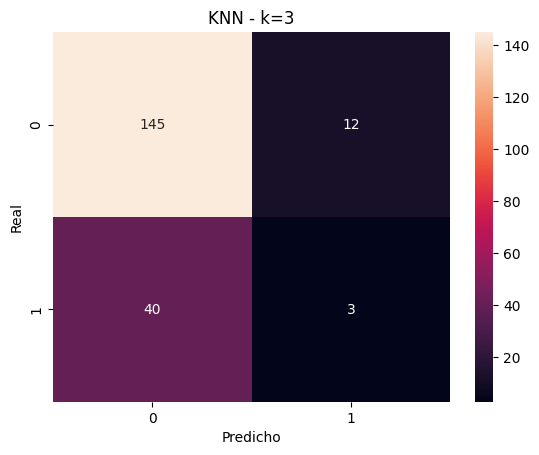

In [410]:
# Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_knn_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("KNN - k=3")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [411]:
# Obtener la precisión, recall y f1
precision_knn_b = precision_score(y_test, y_pred_knn_b, average="macro")
recall_knn_b = recall_score(y_test, y_pred_knn_b, average="macro")
f1_knn_b = f1_score(y_test, y_pred_knn_b, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_knn_b, recall_knn_b, f1_knn_b]})
metricas

,Métricas,Valores
0,Precisión,0.491892
1,Recall,0.496667
2,F1,0.475701


### c) KNN con k=11

Con un valor de `k` más grande, el modelo suaviza las fronteras de decisión y puede ser más robusto al ruido en los datos.

In [412]:
# Crear el objeto de clase KNN con k=11
knn_c = KNeighborsClassifier(n_neighbors=11)
# Ajustar el modelo
knn_c.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [413]:
# Obtener el accuracy score
y_pred_knn_c = knn_c.predict(X_test_scaled)
accuracy_knn_c = accuracy_score(y_test, y_pred_knn_c)
print("El accuracy score que se tiene es %s" % accuracy_knn_c)

El accuracy score que se tiene es 0.78


Text(50.722222222222214, 0.5, 'Real')

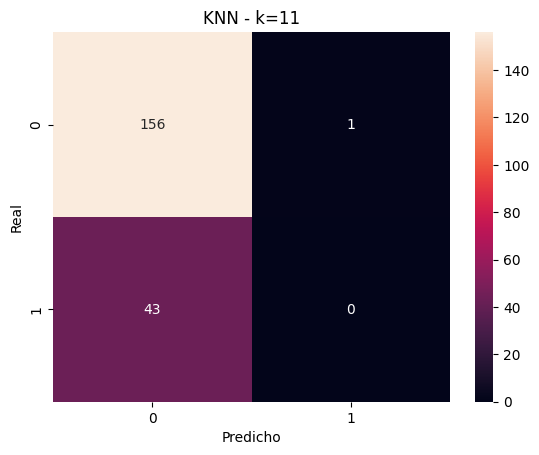

In [414]:
# Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_knn_c)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("KNN - k=11")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [415]:
# Obtener la precisión, recall y f1
precision_knn_c = precision_score(y_test, y_pred_knn_c, average="macro")
recall_knn_c = recall_score(y_test, y_pred_knn_c, average="macro")
f1_knn_c = f1_score(y_test, y_pred_knn_c, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_knn_c, recall_knn_c, f1_knn_c]})
metricas

,Métricas,Valores
0,Precisión,0.391960
1,Recall,0.496815
2,F1,0.438202


### Comparación de los modelos KNN

In [416]:
comparacion_knn = pd.DataFrame({
    'Modelo': ['KNN - k=5 (defecto)', 'KNN - k=3', 'KNN - k=11'],
    'Accuracy': [accuracy_knn_a, accuracy_knn_b, accuracy_knn_c],
    'Precisión': [precision_knn_a, precision_knn_b, precision_knn_c],
    'Recall': [recall_knn_a, recall_knn_b, recall_knn_c],
    'F1': [f1_knn_a, f1_knn_b, f1_knn_c]
})
comparacion_knn

,Modelo,Accuracy,Precisión,Recall,F1
0,KNN - k=5 (defecto),0.77,0.492308,0.498889,0.455492
1,KNN - k=3,0.74,0.491892,0.496667,0.475701
2,KNN - k=11,0.78,0.391960,0.496815,0.438202


---
## 6.Árbol de Decisiones
Un **árbol de decisión** consiste en una secuencia de condiciones sobre las distintas variables predictoras y su relación con la variable de respuesta. Estas condiciones se van sucediendo en distintos caminos del árbol, dividiendo el espacio de los predictores en diferentes regiones.

Se evaluarán tres configuraciones:
- **a)** Parámetros por defecto
- **b)** Profundidad máxima `max_depth=5`
- **c)** Mínimo de muestras en hoja `min_samples_leaf=4`

### a) Árbol de Decisiones con parámetros por defecto

In [417]:
# Crear el objeto de clase árbol
tree_clf_a = DecisionTreeClassifier(random_state=2026)
# Ajustar el árbol
tree_clf_a.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [418]:
# Obtener el accuracy score
y_pred_a = tree_clf_a.predict(X_test)
accuracy_a = accuracy_score(y_test, y_pred_a)
print("El accuracy score que se tiene es %s" % accuracy_a)

El accuracy score que se tiene es 0.68


Text(50.722222222222214, 0.5, 'Real')

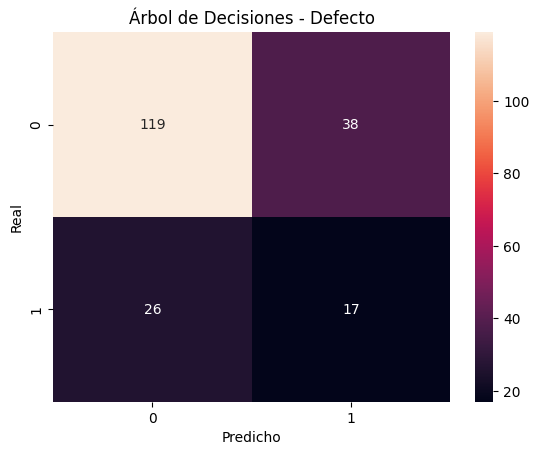

In [419]:
# Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_a)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Árbol de Decisiones - Defecto")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [420]:
# Obtener la precisión, recall y f1
precision_a = precision_score(y_test, y_pred_a, average="macro")
recall_a = recall_score(y_test, y_pred_a, average="macro")
f1_a = f1_score(y_test, y_pred_a, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_a, recall_a, f1_a]})
metricas

,Métricas,Valores
0,Precisión,0.564890
1,Recall,0.576655
2,F1,0.567509


### b) Árbol de Decisiones con profundidad máxima `max_depth=5`

Una manera sencilla de evitar el posible sobreajuste del árbol es fijar un número de profundidad máxima, es decir, del número de divisiones sucesivas que se realizan.

In [421]:
# Crear el objeto de clase árbol con max_depth=5
tree_clf_b = DecisionTreeClassifier(max_depth=5, random_state=2026)
# Ajustar el árbol
tree_clf_b.fit(X_train, y_train)
plt.figure(figsize=(14,10))


<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

[Text(0.5703125, 0.9166666666666666, 'x[10] <= 6.5\ngini = 0.298\nsamples = 800\nvalue = [654, 146]'),
 Text(0.2864583333333333, 0.75, 'x[14] <= 56.5\ngini = 0.325\nsamples = 553\nvalue = [440, 113]'),
 Text(0.42838541666666663, 0.8333333333333333, 'True  '),
 Text(0.15625, 0.5833333333333334, 'x[5] <= 3.5\ngini = 0.36\nsamples = 306\nvalue = [234.0, 72.0]'),
 Text(0.08333333333333333, 0.4166666666666667, 'x[18] <= 4.5\ngini = 0.408\nsamples = 175\nvalue = [125, 50]'),
 Text(0.041666666666666664, 0.25, 'x[12] <= 2.5\ngini = 0.236\nsamples = 44\nvalue = [38, 6]'),
 Text(0.020833333333333332, 0.08333333333333333, 'gini = 0.473\nsamples = 13\nvalue = [8, 5]'),
 Text(0.0625, 0.08333333333333333, 'gini = 0.062\nsamples = 31\nvalue = [30, 1]'),
 Text(0.125, 0.25, 'x[20] <= 2.5\ngini = 0.446\nsamples = 131\nvalue = [87, 44]'),
 Text(0.10416666666666667, 0.08333333333333333, 'gini = 0.375\nsamples = 68\nvalue = [51, 17]'),
 Text(0.14583333333333334, 0.08333333333333333, 'gini = 0.49\nsamples =

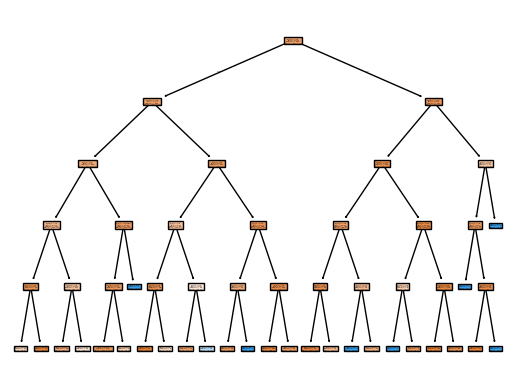

In [422]:
# Visualizar el árbol de decisión
tree.plot_tree(tree_clf_b, filled=True)

In [423]:
# Obtener el accuracy score
y_pred_b = tree_clf_b.predict(X_test)
accuracy_b = accuracy_score(y_test, y_pred_b)
print("El accuracy score que se tiene es %s" % accuracy_b)

El accuracy score que se tiene es 0.765


Text(50.722222222222214, 0.5, 'Real')

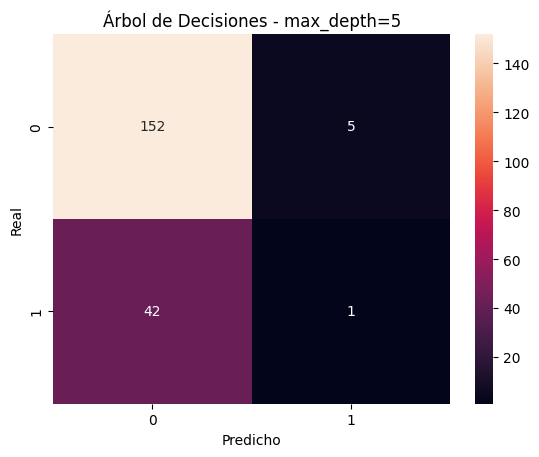

In [424]:
# Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Árbol de Decisiones - max_depth=5")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [425]:
# Obtener la precisión, recall y f1
precision_b = precision_score(y_test, y_pred_b, average="macro")
recall_b = recall_score(y_test, y_pred_b, average="macro")
f1_b = f1_score(y_test, y_pred_b, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_b, recall_b, f1_b]})
metricas



,Métricas,Valores
0,Precisión,0.475086
1,Recall,0.495704
2,F1,0.453457


### c) Árbol de Decisiones indicando que el mínimo número de observaciones que debe contener cada nodo hoja es de 4.

Otra manera de restringir la longitud del árbol de decisión sin fijar la profundidad máxima es indicando el número mínimo de observaciones que debe contener cada nodo hoja. En este caso se fijará el valor de `min_samples_leaf=4`.

In [426]:
# Crear el objeto de clase árbol
tree_clf_c = DecisionTreeClassifier(min_samples_leaf=4, random_state=2026)  # 4 muestras
# Ajustar el arbol
tree_clf_c.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.6492718446601942, 0.9583333333333334, 'x[10] <= 6.5\ngini = 0.298\nsamples = 800\nvalue = [654, 146]'),
 Text(0.375, 0.875, 'x[14] <= 56.5\ngini = 0.325\nsamples = 553\nvalue = [440, 113]'),
 Text(0.5121359223300971, 0.9166666666666667, 'True  '),
 Text(0.2275485436893204, 0.7916666666666666, 'x[5] <= 3.5\ngini = 0.36\nsamples = 306\nvalue = [234.0, 72.0]'),
 Text(0.1104368932038835, 0.7083333333333334, 'x[18] <= 4.5\ngini = 0.408\nsamples = 175\nvalue = [125, 50]'),
 Text(0.038834951456310676, 0.625, 'x[12] <= 2.5\ngini = 0.236\nsamples = 44\nvalue = [38, 6]'),
 Text(0.019417475728155338, 0.5416666666666666, 'x[8] <= 15.5\ngini = 0.473\nsamples = 13\nvalue = [8, 5]'),
 Text(0.009708737864077669, 0.4583333333333333, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.02912621359223301, 0.4583333333333333, 'x[9] <= 6.5\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.019417475728155338, 0.375, 'gini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.038834951456310676, 0.375,

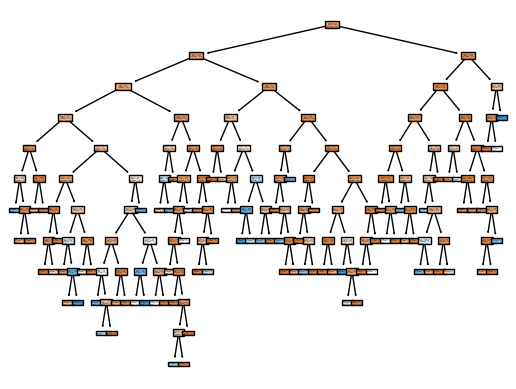

In [427]:
from sklearn import tree
tree.plot_tree(tree_clf_c, filled=True)

In [428]:
# Obtener el accuracy_score
y_pred_c = tree_clf_c.predict(X_test)
accuracy_c = accuracy_score(y_test, y_pred_c)
print("El accuracy score que se tiene es %s" % accuracy_c)

El accuracy score que se tiene es 0.71


Text(50.722222222222214, 0.5, 'Real')

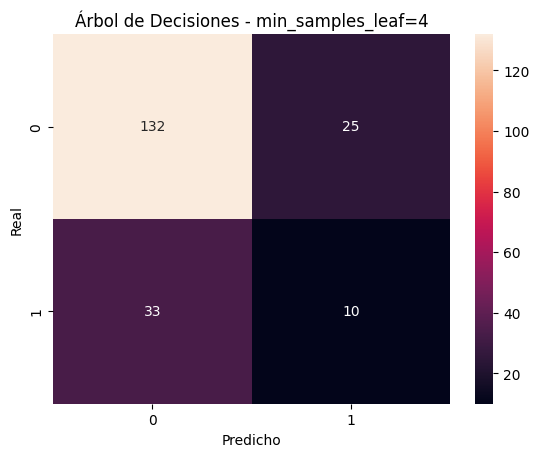

In [429]:
# Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_c)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Árbol de Decisiones - min_samples_leaf=4")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [430]:
# Obtener la precisión, recall y f1
precision_c = precision_score(y_test, y_pred_c, average="macro")
recall_c = recall_score(y_test, y_pred_c, average="macro")
f1_c = f1_score(y_test, y_pred_c, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"],
                          "Valores": [precision_c, recall_c, f1_c]})
metricas

,Métricas,Valores
0,Precisión,0.542857
1,Recall,0.536661
2,F1,0.538143


### Comparación de los modelos de Árbol de Decisiones

In [431]:
comparacion_tree = pd.DataFrame({
    'Modelo': ['Árbol - Defecto', 'Árbol - max_depth=5', 'Árbol - min_samples_leaf=4'],
    'Accuracy': [accuracy_a, accuracy_b, accuracy_c],
    'Precisión': [precision_a, precision_b, precision_c],
    'Recall': [recall_a, recall_b, recall_c],
    'F1': [f1_a, f1_b, f1_c]
})
comparacion_tree

,Modelo,Accuracy,Precisión,Recall,F1
0,Árbol - Defecto,0.680,0.564890,0.576655,0.567509
1,Árbol - max_depth=5,0.765,0.475086,0.495704,0.453457
2,Árbol - min_samples_leaf=4,0.710,0.542857,0.536661,0.538143


---
## 7. Comparación Global de todos los Algoritmos

A continuación se presenta un resumen consolidado de todos los modelos entrenados, permitiendo identificar el mejor algoritmo para la detección temprana de abandono laboral.

In [432]:
comparacion_global = pd.DataFrame({
    'Algoritmo': [
        'Regresión Logística (defecto)',
        'Regresión Logística (L1)',
        'Regresión Logística (C=0.5)',
        'KNN (k=5)',
        'KNN (k=3)',
        'KNN (k=11)',
        'Árbol de Decisión (defecto)',
        'Árbol de Decisión (max_depth=5)',
        'Árbol de Decisión (min_samples_leaf=4)'
    ],
    'Accuracy': [
        accuracy_lr_a, accuracy_lr_b, accuracy_lr_c,
        accuracy_knn_a, accuracy_knn_b, accuracy_knn_c,
        accuracy_a, accuracy_b, accuracy_c
    ],
    'F1 (macro)': [
        f1_lr_a, f1_lr_b, f1_lr_c,
        f1_knn_a, f1_knn_b, f1_knn_c,
        f1_a, f1_b, f1_c
    ]
})

comparacion_global.sort_values('F1 (macro)', ascending=False).reset_index(drop=True)

,Algoritmo,Accuracy,F1 (macro)
0,Árbol de Decisión (defecto),0.680,0.567509
1,Árbol de Decisión (min_samples_leaf=4),0.710,0.538143
2,KNN (k=3),0.740,0.475701
3,KNN (k=5),0.770,0.455492
4,Árbol de Decisión (max_depth=5),0.765,0.453457
5,Regresión Logística (defecto),0.785,0.439776
6,Regresión Logística (C=0.5),0.785,0.439776
7,Regresión Logística (L1),0.785,0.439776
8,KNN (k=11),0.780,0.438202


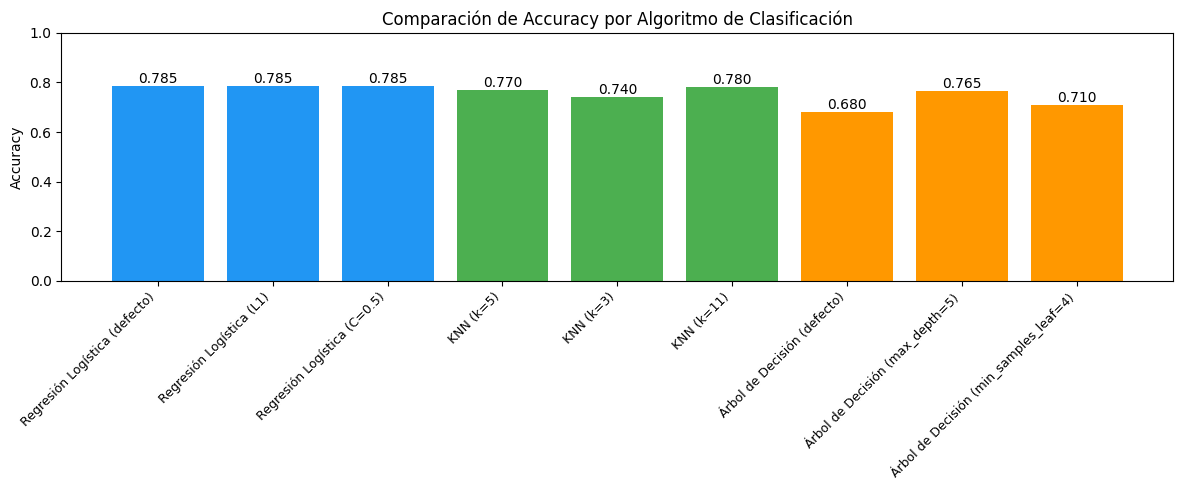

In [433]:
# Gráfico comparativo de Accuracy por algoritmo
plt.figure(figsize=(12, 5))
colores = ['#2196F3'] * 3 + ['#4CAF50'] * 3 + ['#FF9800'] * 3
barras = plt.bar(range(9), comparacion_global['Accuracy'], color=colores)
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, altura, f'{altura:.3f}',
             ha='center', va='bottom')
plt.xticks(range(9), comparacion_global['Algoritmo'], rotation=45, ha='right', fontsize=9)
plt.ylabel('Accuracy')
plt.title('Comparación de Accuracy por Algoritmo de Clasificación')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

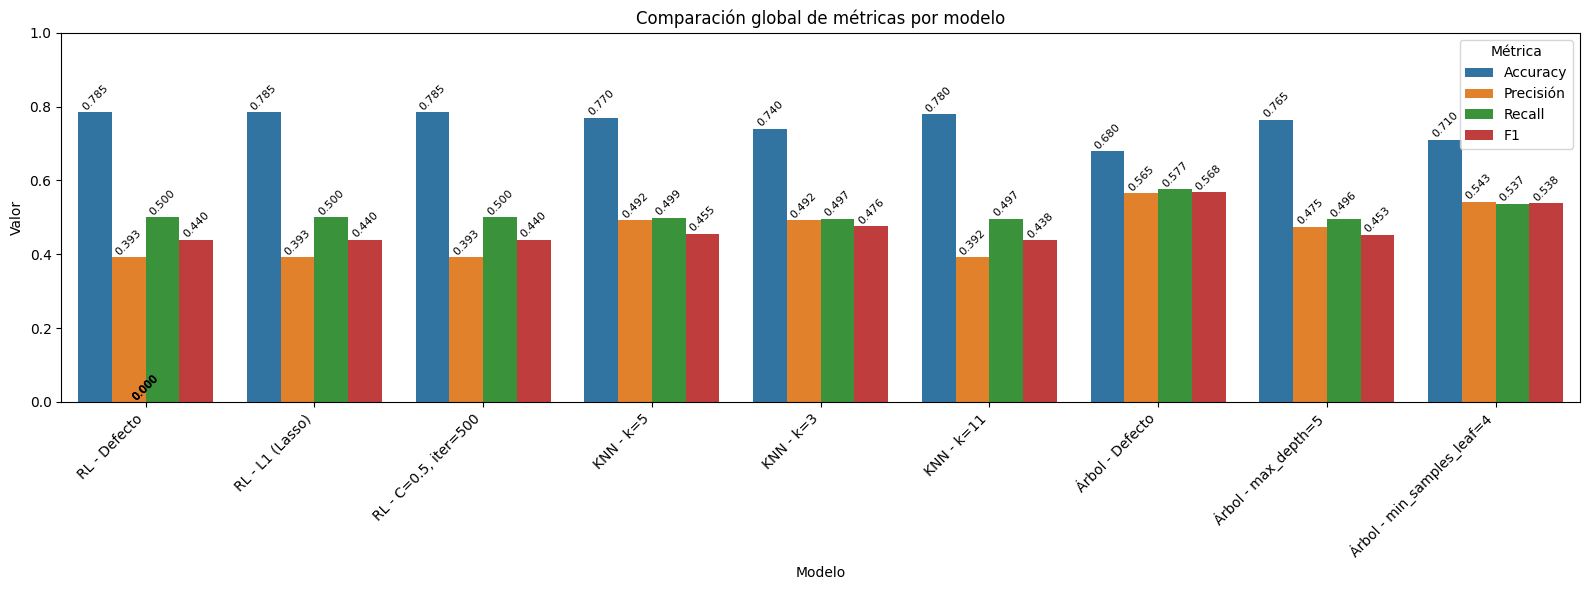

In [442]:
#Comparación global de todas las métricas
comparacion_metricas_global = pd.DataFrame({
    'Modelo': [
        'RL - Defecto',
        'RL - L1 (Lasso)',
        'RL - C=0.5, iter=500',
        'KNN - k=5',
        'KNN - k=3',
        'KNN - k=11',
        'Árbol - Defecto',
        'Árbol - max_depth=5',
        'Árbol - min_samples_leaf=4'
    ],
    'Accuracy': [
        accuracy_lr_a, accuracy_lr_b, accuracy_lr_c,
        accuracy_knn_a, accuracy_knn_b, accuracy_knn_c,
        accuracy_a, accuracy_b, accuracy_c
    ],
    'Precisión': [
        precision_lr_a, precision_lr_b, precision_lr_c,
        precision_knn_a, precision_knn_b, precision_knn_c,
        precision_a, precision_b, precision_c
    ],
    'Recall': [
        recall_lr_a, recall_lr_b, recall_lr_c,
        recall_knn_a, recall_knn_b, recall_knn_c,
        recall_a, recall_b, recall_c
    ],
    'F1': [
        f1_lr_a, f1_lr_b, f1_lr_c,
        f1_knn_a, f1_knn_b, f1_knn_c,
        f1_a, f1_b, f1_c
    ]
})

comparacion_metricas_larga = comparacion_metricas_global.melt(
    id_vars='Modelo',
    var_name='Métrica',
    value_name='Valor'
)

plt.figure(figsize=(16, 6))
ax = sns.barplot(x='Modelo', y='Valor', hue='Métrica', data=comparacion_metricas_larga)
for p in ax.patches:
    valor = p.get_height()
    ax.annotate(f'{valor:.3f}',
                (p.get_x() + p.get_width() / 2, valor),
                ha='center', va='bottom', fontsize=8, rotation=45)
plt.title('Comparación global de métricas por modelo')
plt.xlabel('Modelo')
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()


## 8. Conclusiones

Con base en los resultados obtenidos a partir de la aplicación de los tres algoritmos de clasificación (Regresión Logística, KNN y Árbol de Decisiones) sobre el conjunto de datos de abandono laboral, se pueden extraer las siguientes conclusiones:

1. **Regresión Logística**: Ofrece un rendimiento sólido y estable entre sus diferentes configuraciones. La regularización permite controlar el sobreajuste y mejorar la generalización del modelo.

2. **KNN**: Es sensible al valor de `k`. Valores muy pequeños de `k` pueden provocar sobreajuste, mientras que valores muy grandes pueden suavizar en exceso las fronteras de decisión. Es importante normalizar los datos antes de aplicar este algoritmo.

3. **Árbol de Decisiones**: Sin restricciones puede sobreajustarse completamente a los datos de entrenamiento. La limitación de la profundidad máxima (`max_depth`) o del número mínimo de muestras por hoja (`min_samples_leaf`) ayuda a construir modelos más generalizables.

La selección del mejor modelo debe considerar no solo el `accuracy`, sino también métricas como `F1`, `precision` y `recall`, especialmente cuando existe desbalance de clases en la variable objetivo `Attrition`.